In [201]:

import geopandas as gpd

gdf = gpd.read_file("/home/jovyan/climmath/extract/data/Topo_40ft_1999_SG.shp")

print(gdf.columns)


Index(['objectid', 'elevation', 'stlength__', 'globalid', 'shape_Leng',
       'geometry'],
      dtype='object')


In [202]:
# fill in the missing values 
print(gdf["elevation"].max())


print("Missing elevation:", gdf["objectid"].isna().sum())


8680
Missing elevation: 0


<Axes: >

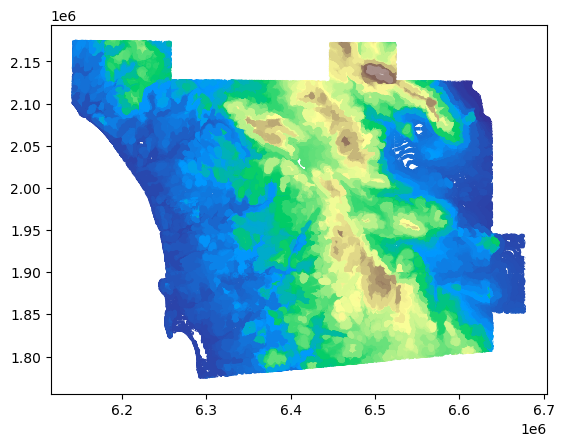

In [2]:

gdf.plot(column="elevation", cmap="terrain", linewidth = 2.5)

In [203]:
gdf["elevation"].shape


gdf_latlon = gdf.to_crs("EPSG:4326")

In [204]:
import numpy as np 
# --- extract coordinates from geometry ---
coords = gdf_latlon['geometry'].apply(lambda geom: list(geom.coords))
coords_flat = [point for line in coords for point in line]

grid_lons = np.array([c[0] for c in coords_flat])
grid_lats = np.array([c[1] for c in coords_flat])

print(f"Lon range: {grid_lons.min():.4f} to {grid_lons.max():.4f}")
print(f"Lat range: {grid_lats.min():.4f} to {grid_lats.max():.4f}")
print(f"Total points: {len(grid_lons)}")

Lon range: -117.6261 to -115.8757
Lat range: 32.5344 to 33.6254
Total points: 18649541


In [205]:
import geopandas as gpd
from shapely.geometry import Point

# --- station list ---
stations = [
    ("San Diego International Airport", 32.7336, -117.1831),
    ("San Diego Brown field", 32.57583, -116.99391),
    ("Montgomery field", 32.81453, -117.13747),
    ("Miramar", 32.8685, -117.14319),
    ("Chula Vista", 32.64, -117.0858),
    ("Imperial Beach", 32.56797, -117.11715),
    ("North Island", 32.69219, -117.20983),
    ("Alpine", 32.8358, -116.7774),
    ("El Cajon", 32.8005, -116.928),
    ("Seaworld", 32.76536, -117.2315),
    ("La Mesa", 32.7675, -117.0233),
    ("Carlsbad", 33.12993, -117.27651), 
    ("Ramona", 33.03801, -116.915979),
    ("Camp Pendleton", 33.30424, -117.35508),
    ("Oceanside", 33.21946, -117.34962),
    ("Henshaw Dam", 33.2372, -116.7614),
    ("Borrego desert park", 33.2559, -116.4036),
    ("Campo", 32.6263, -116.4699),
    ("Potrero", 32.6058, -116.6089),
    ("Valley center", 33.2372, -117.0086),
    ("Julian", 33.0758, -116.5908),
    ("Cameron Fire Station", 32.7214, -116.4631),
    ("Ranchita", 33.2222, -116.4975),
    ("Oak Grove", 33.3933, -116.795),
    ("Mount Laguna", 32.8797, -116.4203),
    ("San Miguel", 32.685, -116.9736),
    ("Cuyamaca", 32.9897, -116.5872),
    ("Palomar Mountain", 33.378, -116.84),
    ("Escondido", 33.121, -117.09),
    ("Poway", 33.01953, -117.03096),
    ("Vista", 33.2354, -117.2322)
    
    
    
]

# --- project contours once (important for speed) ---
contours_proj = gdf_latlon.to_crs("EPSG:3310")

# --- loop ---
results = []

for name, lat, lon in stations:
    point = gpd.GeoDataFrame(
        geometry=[Point(lon, lat)],
        crs="EPSG:4326"
    )

    point_proj = point.to_crs("EPSG:3310")

    nearest = gpd.sjoin_nearest(
        point_proj,
        contours_proj[["elevation", "geometry"]],
        how="left",
        distance_col="distance_m"
    )

    elev = nearest["elevation"].values[0]
    dist = nearest["distance_m"].values[0]

    results.append((name, lat, lon, elev, dist))

# --- print results ---
for r in results:
    print(f"{r[0]}: elevation={r[3]} ft")

San Diego International Airport: elevation=10 ft
San Diego Brown field: elevation=520 ft
Montgomery field: elevation=410 ft
Miramar: elevation=450 ft
Chula Vista: elevation=80 ft
Imperial Beach: elevation=10 ft
North Island: elevation=10 ft
Alpine: elevation=1680 ft
El Cajon: elevation=510 ft
Seaworld: elevation=10 ft
La Mesa: elevation=520 ft
Carlsbad: elevation=320 ft
Ramona: elevation=1400 ft
Camp Pendleton: elevation=70 ft
Oceanside: elevation=30 ft
Henshaw Dam: elevation=2720 ft
Borrego desert park: elevation=800 ft
Campo: elevation=2600 ft
Potrero: elevation=2360 ft
Valley center: elevation=1480 ft
Julian: elevation=4200 ft
Cameron Fire Station: elevation=3280 ft
Ranchita: elevation=4400 ft
Oak Grove: elevation=2720 ft
Mount Laguna: elevation=6000 ft
San Miguel: elevation=600 ft
Cuyamaca: elevation=4640 ft
Palomar Mountain: elevation=4480 ft
Escondido: elevation=640 ft
Poway: elevation=640 ft
Vista: elevation=440 ft


EPSG:4326


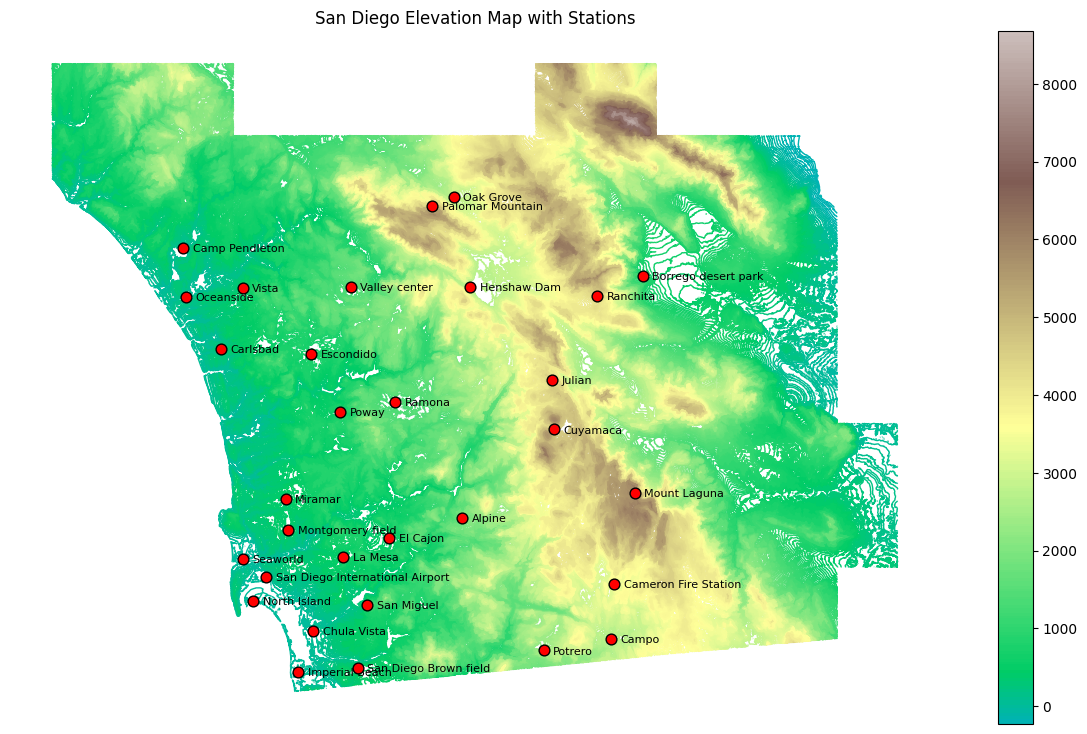

In [56]:
print(gdf_latlon.crs)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import ListedColormap


terrain = plt.get_cmap("terrain")
land_colors = terrain(np.linspace(0.2, 0.9, 256))

land_cmap = ListedColormap(land_colors)

points = gpd.GeoDataFrame(
    [(name, Point(lon, lat)) for name, lat, lon in stations],
    columns=["name", "geometry"],
    crs="EPSG:4326"
)

# --- plot ---
fig, ax = plt.subplots(figsize=(15, 15))

# contour lines
gdf_latlon.plot(
    column="elevation",
    cmap= land_cmap,
    legend=True,
    ax=ax,
    linewidth=1,
    legend_kwds={"shrink": 0.6}
)

# plot stations
points.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    markersize=60,
    zorder=5
)

# --- label stations ---
for idx, row in points.iterrows():
    ax.text(
        row.geometry.x + 0.02,
        row.geometry.y - 0.01,
        row["name"],
        fontsize=8,
        ha="left",
        va="bottom"
    )

ax.set_title("San Diego Elevation Map with Stations")
ax.set_axis_off()
plt.savefig("elevationsd.png")

plt.show()

In [173]:
elevation = [
    ("San Diego International Airport", 10),
    ("San Diego Brown field",           520),
    ("Montgomery field",                410),
    ("Miramar",                         450),
    ("Chula Vista",                     80),
    ("Imperial Beach",                  10),
    ("North Island",                    10),
    ("Alpine",                          1680),
    ("El Cajon",                        510),
    ("Seaworld",                        10),
    ("La Mesa",                         520),
    ("Carlsbad",                        320),
    ("Ramona",                          1400),
    ("Camp Pendleton",                  70),
    ("Oceanside",                       30),
    ("Henshaw Dam",                     2720),
    ("Borrego Park",                    800),
    ("Campo",                           2600),
    ("Potrero",                         2360),
    ("Valley Center",                   1480),
    ("Julian",                          4200),
    ("Cameron",                         3280),
    ("Ranchita",                        4400),
    ("Oak Grove",                       2720),
    ("Mount Laguna",                    6000),
    ("San Miguel",                      600),
    ("Cuyamaca",                        4640),
    ("Palomar",                         4480),
    ("Escondido",                       640),
    ("Poway",                           640),
    ("Vista",                           440),
]

def station_temp_std(elev_ft):
    L  = 0.00309 # K/m
    T0 = 291.15  
    
    z     = elev_ft * 0.3048
    T_K   = T0 - L * z
    T_C   = T_K - 273.15
    
    return T_K, T_C

# --- compute ---
print(f"{'Station':<40} {'Elev(ft)':>8} {'T(K)':>8} {'T(°C)':>8}")
print("-" * 68)
for name, elev_ft in elevation:
    T_K, T_C = station_temp_std(elev_ft)
    print(f"{name:<40} {elev_ft:>8} {T_K:>8.2f} {T_C:>8.2f}")

Station                                  Elev(ft)     T(K)    T(°C)
--------------------------------------------------------------------
San Diego International Airport                10   291.14    17.99
San Diego Brown field                         520   290.66    17.51
Montgomery field                              410   290.76    17.61
Miramar                                       450   290.73    17.58
Chula Vista                                    80   291.07    17.92
Imperial Beach                                 10   291.14    17.99
North Island                                   10   291.14    17.99
Alpine                                       1680   289.57    16.42
El Cajon                                      510   290.67    17.52
Seaworld                                       10   291.14    17.99
La Mesa                                       520   290.66    17.51
Carlsbad                                      320   290.85    17.70
Ramona                                       14

In [215]:
import pandas as pd
import glob
from pathlib import Path

def clean_data(df, name):
    start_date = '1976-01-01'
    end_date = '2025-01-01'
    df['Date'] = pd.to_datetime(df['Date'])
    df = df[df['Date'].between(start_date, end_date)]
    df = df[['Date', 'TMAX (Degrees Fahrenheit)', 'TMIN (Degrees Fahrenheit)']]
    df['Year'] = df['Date'].dt.year
    df['Month_Day'] = df['Date'].dt.strftime('%m-%d')
    df = df.set_index('Date')
    df['TMAX (Degrees Fahrenheit)'] = df['TMAX (Degrees Fahrenheit)'].astype(float)
    df['TMIN (Degrees Fahrenheit)'] = df['TMIN (Degrees Fahrenheit)'].astype(float)
    df[name] = (df['TMAX (Degrees Fahrenheit)'] + df['TMIN (Degrees Fahrenheit)']) / 2
    df = df[[name]]
    return df

folder_path = '/home/jovyan/climmath/extract/data/SanDiegoStations/'
all_files = glob.glob(folder_path + "*.csv")

temp_dfs = []
for files in all_files:
    file_path = Path(files).stem
    data = pd.read_csv(files, skiprows=1, sep=',')
    data = clean_data(data, file_path)
    temp_dfs.append(data)

new_data = pd.concat(temp_dfs, axis=1)
#new_data = new_data.T
print(new_data.shape)
print(new_data)

(17899, 31)
            Brownfield  ElCajon  ChulaVista  Montgomery  ImperialBeach  \
Date                                                                     
1976-01-01         NaN      NaN        49.5         NaN           45.0   
1976-01-02         NaN      NaN        43.0         NaN           46.0   
1976-01-03         NaN      NaN        43.5         NaN           46.5   
1976-01-04         NaN      NaN        46.5         NaN           47.5   
1976-01-05         NaN      NaN        48.0         NaN           51.0   
...                ...      ...         ...         ...            ...   
2024-12-28        55.0     57.5        55.5        55.5            NaN   
2024-12-29        53.5     54.5        54.5        53.5            NaN   
2024-12-30        54.0     56.0        54.5        56.0            NaN   
2024-12-31        51.0     52.5        53.0        55.5            NaN   
2025-01-01        52.5     53.5        51.5        54.0            NaN   

            SeaWorld  LaM

In [176]:
average = (new_data.mean() - 32)*5/9
average

Brownfield              17.141344
ElCajon                 18.494571
ChulaVista              17.451992
Montgomery              17.827442
ImperialBeach           16.999353
SeaWorld                16.904767
LaMesa                  18.301027
NorthIsland             17.856157
Alpine                  17.720253
InternationalAirport    18.106014
Miramar                 17.703969
Carlsbad                16.994026
CampPendleton           16.923697
Ramona                  16.137777
Oceanside               16.310620
Cameron                 14.478723
Escondido               18.614092
MountLaguna             11.689280
OakGrove                16.840947
Campo                   15.242345
HenshawDam              14.113352
Potrero                 16.092398
Julian                  14.808668
Ranchita                15.978708
SanMiguel               18.279029
ValleyCenter            17.866870
Cuyamaca                12.222831
Vista                   17.637856
BorregoPark             23.148253
Poway         

In [216]:
name_map = {
    "San Diego International Airport": "InternationalAirport",
    "San Diego Brown field":           "Brownfield",
    "Montgomery field":                "Montgomery",
    "Miramar":                         "Miramar",
    "Chula Vista":                     "ChulaVista",
    "Imperial Beach":                  "ImperialBeach",
    "North Island":                    "NorthIsland",
    "Alpine":                          "Alpine",
    "El Cajon":                        "ElCajon",
    "Seaworld":                        "SeaWorld",
    "La Mesa":                         "LaMesa",
    "Carlsbad":                        "Carlsbad",
    "Ramona":                          "Ramona",
    "Camp Pendleton":                  "CampPendleton",
    "Oceanside":                       "Oceanside",
    "Cameron":                         "Cameron",
    "Escondido":                       "Escondido",
    "Mount Laguna":                    "MountLaguna",
    "Oak Grove":                       "OakGrove",
    "Campo":                           "Campo",
    "Henshaw Dam":                     "HenshawDam",
    "Potrero":                         "Potrero",
    "Julian":                          "Julian",
    "Ranchita":                        "Ranchita",
    "San Miguel":                      "SanMiguel",
    "Valley Center":                   "ValleyCenter",
    "Cuyamaca":                        "Cuyamaca",
    "Vista":                           "Vista",
    "Borrego Park":                    "BorregoPark",
    "Poway":                           "Poway",
    "Palomar":                         "Palomar"
}


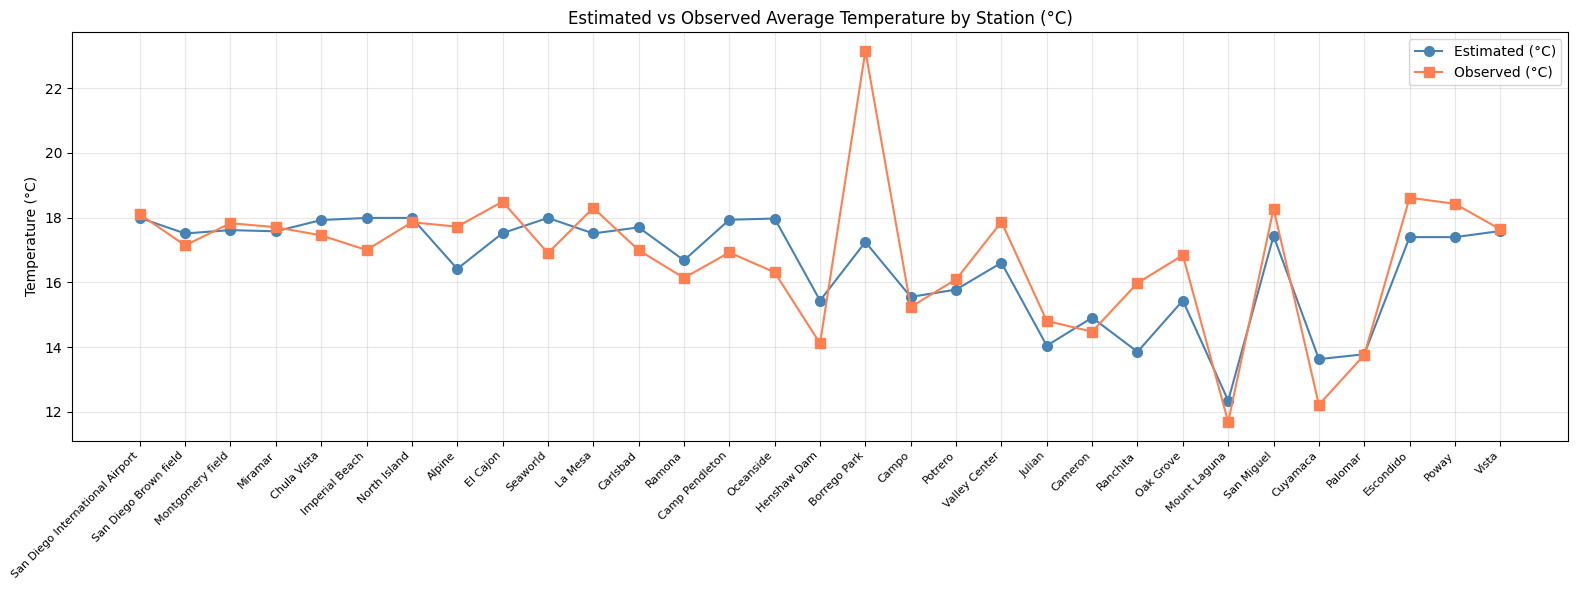

In [179]:
import matplotlib.pyplot as plt
import numpy as np

# --- rebuild comparison with all stations ---
comparison = []
for name, elev_ft in elevation:
    T_K, T_C = station_temp_std(elev_ft)
    mapped   = name_map.get(name)
    T_obs    = average.get(mapped) if mapped else np.nan
    comparison.append((name, elev_ft, T_K, T_C, T_obs))

# --- unpack ---
labels = [r[0] for r in comparison]
t_std  = [r[3] for r in comparison]
t_obs  = [r[4] for r in comparison]
x      = np.arange(len(labels))

# --- plot ---
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(x, t_std, marker='o', linestyle='-', color='steelblue',
        label='Estimated (°C)', markersize=7)
ax.plot(x, t_obs, marker='s', linestyle='-', color='coral',
        label='Observed (°C)', markersize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Temperature (°C)')
ax.set_title('Estimated vs Observed Average Temperature by Station (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tempcompare.png')
plt.show()

This whole dataset is underestimated....

In [70]:
from scipy.stats import linregress
import numpy as np

# --- build aligned arrays dropping None ---
elev_m    = []
obs_temps = []

for name, elev in elevation:
    mapped = name_map.get(name)
    temp   = average.get(mapped) if mapped else None
    if temp is not None:
        elev_m.append(elev * 0.3048)
        obs_temps.append(temp)
    else:
        print(f"Skipping: {name}")

elev_m    = np.array(elev_m)
obs_temps = np.array(obs_temps)

# --- regression ---
slope, intercept, r, p, se = linregress(elev_m, obs_temps)
print(f"Stations used:       {len(elev_m)}")
print(f"Local lapse rate:    {slope*1000:.4f} K/km")
print(f"ISA standard:        6.5000 K/km")
print(f"R²:                  {r**2:.4f}")

Stations used:       31
Local lapse rate:    -3.0969 K/km
ISA standard:        6.5000 K/km
R²:                  0.5674


In [74]:
obs_temps

array([18.10601404, 17.14134397, 17.82744194, 17.70396869, 17.45199156,
       16.99935272, 17.85615744, 17.72025283, 18.49457116, 16.90476704,
       18.30102711, 16.99402622, 16.13777686, 16.92369715, 16.31062018,
       14.11335217, 23.14825328, 15.24234488, 16.09239761, 17.86686958,
       14.80866839, 14.47872329, 15.97870781, 16.84094656, 11.68927962,
       18.27902888, 12.22283058, 13.75761711, 18.61409214, 18.42642508,
       17.63785559])

In [212]:
stations = [
    ("San Diego International Airport", 32.7336,  -117.1831),
    ("San Diego Brown field",           32.5758,  -116.9939),
    ("Montgomery field",                32.8145,  -117.1375),
    ("Miramar",                         32.8685,  -117.1432),
    ("Chula Vista",                     32.6400,  -117.0858),
    ("Imperial Beach",                  32.5680,  -117.1172),
    ("North Island",                    32.6922,  -117.2098),
    ("Alpine",                          32.8358,  -116.7774),
    ("El Cajon",                        32.8005,  -116.9280),
    ("Seaworld",                        32.7654,  -117.2315),
    ("La Mesa",                         32.7675,  -117.0233),
    ("Carlsbad",                        33.1299,  -117.2765),
    ("Ramona",                          33.0380,  -116.9160),
    ("Camp Pendleton",                  33.3042,  -117.3551),
    ("Oceanside",                       33.2195,  -117.3496),
    ("Henshaw Dam",                     33.2413,  -116.7458),
    ("Borrego Park",                    33.2553,  -116.3950),
    ("Campo",                           32.6029,  -116.4694),
    ("Potrero",                         32.5988,  -116.6072),
    ("Valley Center",                   33.2197,  -116.9908),
    ("Julian",                          33.0786,  -116.6019),
    ("Cameron",                         32.7214, -116.4631),
    ("Ranchita",                        33.2239,  -116.5267),
    ("Oak Grove",                       33.3925,  -116.7803),
    ("Mount Laguna",                    32.8697,  -116.4283),
    ("San Miguel",                      32.7000,  -116.9500),
    ("Cuyamaca",                        32.9833,  -116.5667),
    ("Palomar",                         33.3606,  -116.8661),
    ("Escondido",                       33.1192,  -117.0864),
    ("Poway",                           32.9628,  -117.0359),
    ("Vista",                           33.2000,  -117.2425)
]


elevation = [
    ("San Diego International Airport", 10),
    ("San Diego Brown field",           520),
    ("Montgomery field",                410),
    ("Miramar",                         450),
    ("Chula Vista",                     80),
    ("Imperial Beach",                  10),
    ("North Island",                    10),
    ("Alpine",                          1680),
    ("El Cajon",                        510),
    ("Seaworld",                        10),
    ("La Mesa",                         520),
    ("Carlsbad",                        320),
    ("Ramona",                          1400),
    ("Camp Pendleton",                  70),
    ("Oceanside",                       30),
    ("Henshaw Dam",                     2720),
    ("Borrego Park",                    800),
    ("Campo",                           2600),
    ("Potrero",                         2360),
    ("Valley Center",                   1480),
    ("Julian",                          4200),
    ("Cameron",                         3280),
    ("Ranchita",                        4400),
    ("Oak Grove",                       2720),
    ("Mount Laguna",                    6000),
    ("San Miguel",                      600),
    ("Cuyamaca",                        4640),
    ("Palomar",                         4480),
    ("Escondido",                       640),
    ("Poway",                           640),
    ("Vista",                           440),
]

elev_dict = {name: elev for name, elev in elevation}

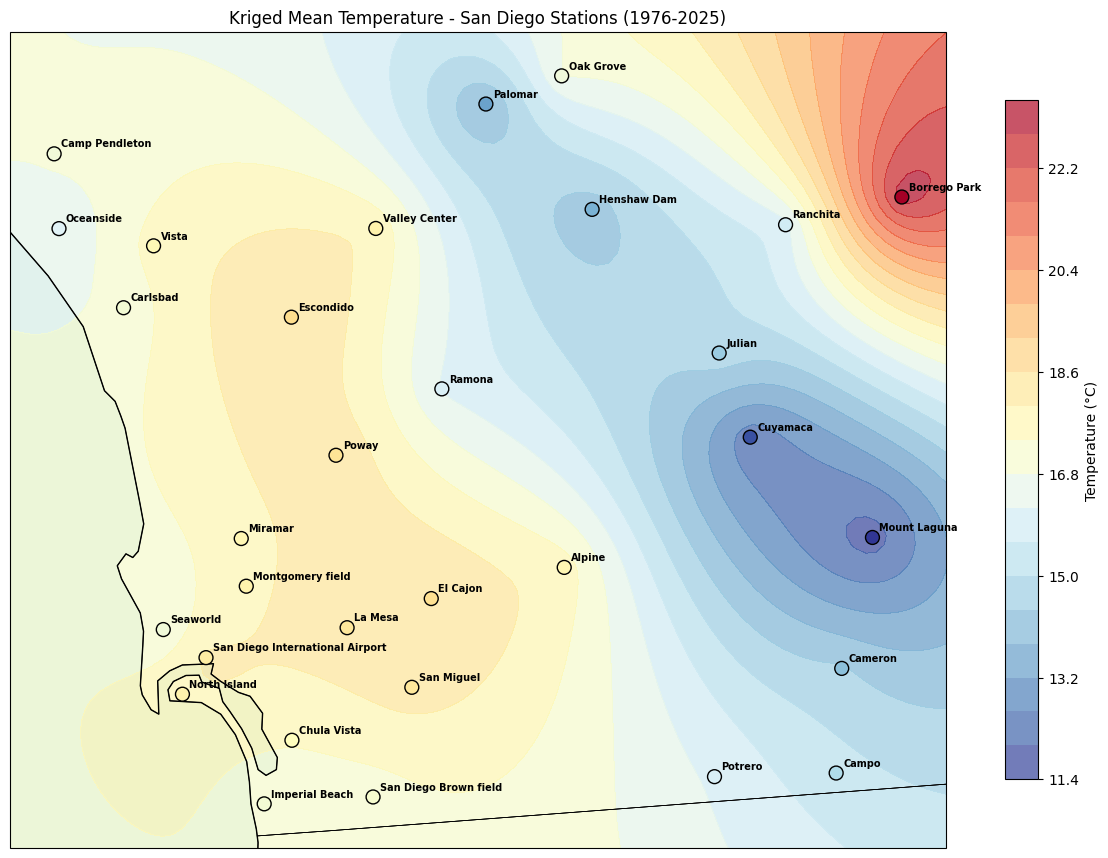

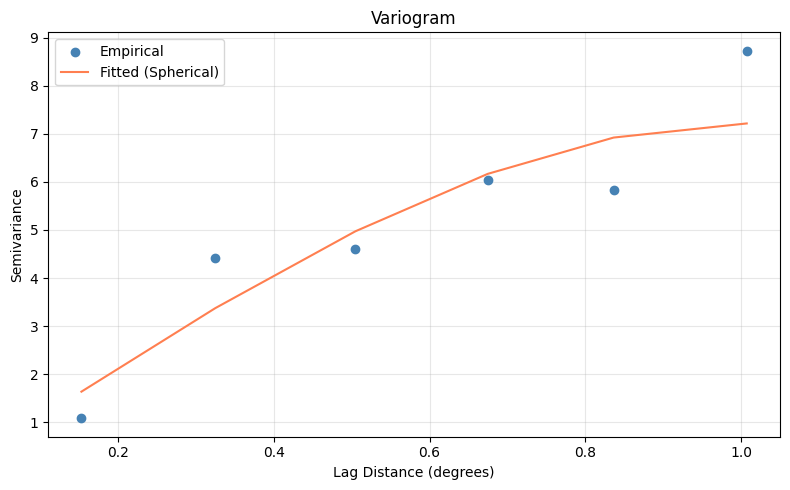

In [230]:
from pykrige.ok import OrdinaryKriging
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# --- unpack stations ---
station_names = [s[0] for s in stations]
lats          = [s[1] for s in stations]
lons          = [s[2] for s in stations]
obs_temps     = [average.get(name_map[name]) for name in station_names]
# --- fit kriging model ---
ok = OrdinaryKriging(
    lons, lats, obs_temps,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False
)
# --- prediction grid ---
grid_lon = np.linspace(min(lons) - 0.1, max(lons) + 0.1, 100)
grid_lat = np.linspace(min(lats) - 0.1, max(lats) + 0.1, 100)
z, ss = ok.execute('grid', grid_lon, grid_lat)
# --- plot with cartopy ---
fig, ax = plt.subplots(figsize=(12, 10),
                        subplot_kw={'projection': ccrs.PlateCarree()})
# --- base map features ---
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5)
ax.add_feature(cfeature.STATES,    linewidth=0.5)
ax.add_feature(cfeature.OCEAN,     color='lightblue', alpha=0.5)
ax.add_feature(cfeature.LAND,      color='whitesmoke', alpha=0.3)
# --- kriging contour ---
contour = ax.contourf(grid_lon, grid_lat, z,
                       levels=20, cmap='RdYlBu_r',
                       alpha=0.7,
                       transform=ccrs.PlateCarree())
# --- station scatter ---
scatter = ax.scatter(lons, lats, c=obs_temps, cmap='RdYlBu_r',
                     edgecolors='black', s=100, zorder=5,
                     transform=ccrs.PlateCarree())
# --- station labels ---
for name, lat, lon in zip(station_names, lats, lons):
    ax.annotate(name,
                xy=(lon, lat),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=7,
                fontweight='bold',
                transform=ccrs.PlateCarree(),
                zorder=6)
# --- colorbar ---
plt.colorbar(contour, ax=ax, label='Temperature (°C)', shrink=0.7)
# --- extent ---
ax.set_extent([min(lons) - 0.05, max(lons) + 0.05,
               min(lats) - 0.05, max(lats) + 0.05],
               crs=ccrs.PlateCarree())
ax.set_title('Kriged Mean Temperature - San Diego Stations (1976-2025)', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.savefig('kriginginterp.png')
plt.tight_layout()
plt.show()


fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.scatter(ok.lags, ok.semivariance,
            color='steelblue', label='Empirical', zorder=5)
ax1.plot(ok.lags,
         ok.variogram_function(ok.variogram_model_parameters, ok.lags),
         color='coral', label='Fitted (Spherical)')
ax1.set_xlabel('Lag Distance (degrees)')
ax1.set_ylabel('Semivariance')
ax1.set_title('Variogram')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('variogram.png')
plt.show()

In [234]:
import requests
r = requests.get('https://api.open-elevation.com/api/v1/lookup?locations=32.73,-117.18')
print(r.status_code)
print(r.text)

200
{"results":[{"latitude":32.73,"longitude":-117.18,"elevation":-1.0}]}


Elevation coefficient: -0.0031 °C/m
R²: 0.5674


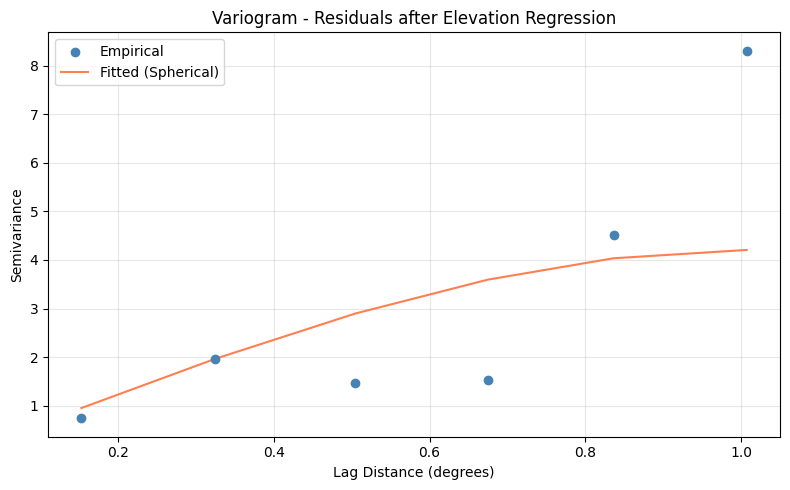

Fetching elevation grid...


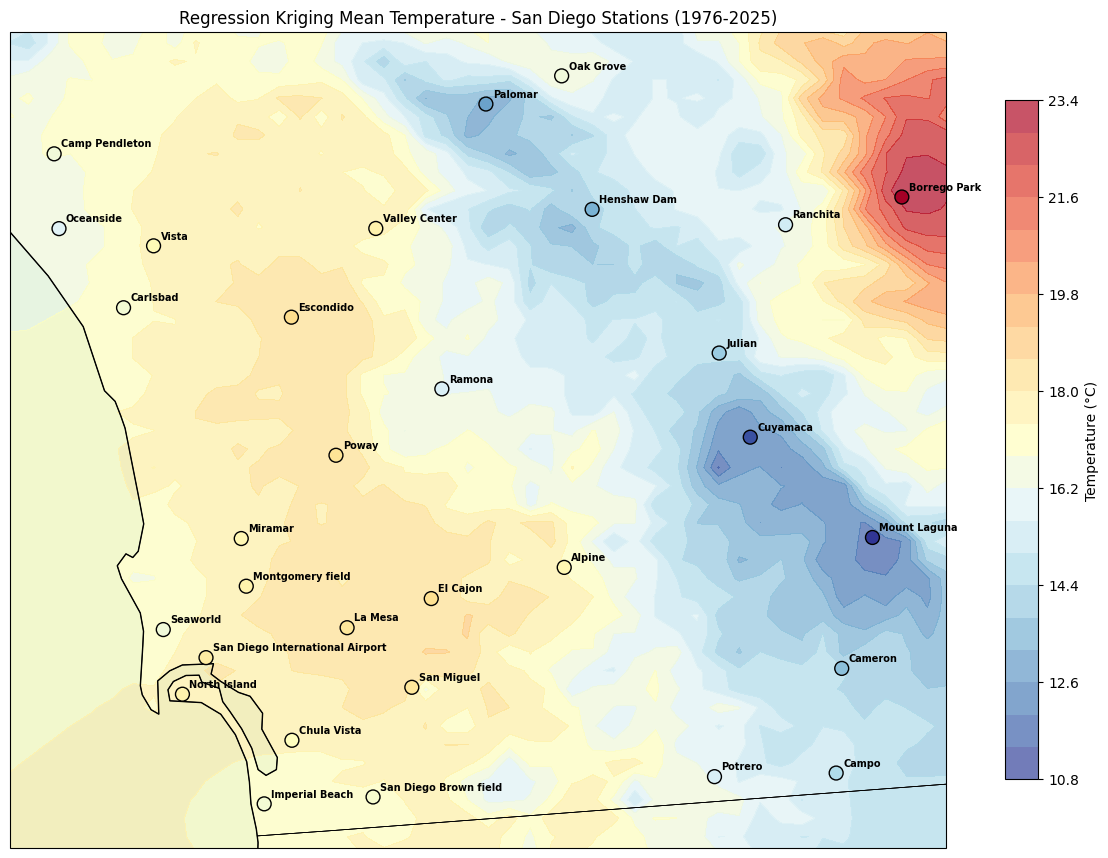

In [236]:
from pykrige.ok import OrdinaryKriging
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- unpack stations ---
station_names = [s[0] for s in stations]
lats          = [s[1] for s in stations]
lons          = [s[2] for s in stations]
obs_temps     = np.array([average.get(name_map[name]) for name in station_names])
elevations_m  = np.array([elev_dict[name] * 0.3048 for name in station_names])

# --- step 1: regression on elevation ---
reg = LinearRegression()
reg.fit(elevations_m.reshape(-1, 1), obs_temps)
trend     = reg.predict(elevations_m.reshape(-1, 1))
residuals = obs_temps - trend

print(f"Elevation coefficient: {reg.coef_[0]:.4f} °C/m")
print(f"R²: {reg.score(elevations_m.reshape(-1, 1), obs_temps):.4f}")

# --- step 2: krige the residuals ---
ok = OrdinaryKriging(
    lons, lats, residuals,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False
)

# --- variogram plot ---
fig_v, ax_v = plt.subplots(figsize=(8, 5))
ax_v.scatter(ok.lags, ok.semivariance,
             color='steelblue', label='Empirical', zorder=5)
ax_v.plot(ok.lags,
          ok.variogram_function(ok.variogram_model_parameters, ok.lags),
          color='coral', label='Fitted (Spherical)')
ax_v.set_xlabel('Lag Distance (degrees)')
ax_v.set_ylabel('Semivariance')
ax_v.set_title('Variogram - Residuals after Elevation Regression')
ax_v.legend()
ax_v.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('variogram_elev.png')
plt.show()

# --- step 3: prediction grid ---
grid_lon = np.linspace(min(lons) - 0.1, max(lons) + 0.1, 50)
grid_lat = np.linspace(min(lats) - 0.1, max(lats) + 0.1, 50)
grid_lon_2d, grid_lat_2d = np.meshgrid(grid_lon, grid_lat)

z_resid, ss = ok.execute('grid', grid_lon, grid_lat)

# --- step 4: elevation grid via open-elevation API ---
def get_elevation_grid(lat_2d, lon_2d, batch_size=50):
    import requests
    import time

    flat_lats  = lat_2d.flatten()
    flat_lons  = lon_2d.flatten()
    elevations = []

    for i in range(0, len(flat_lats), batch_size):
        batch = "|".join([f"{la},{lo}" for la, lo in
                          zip(flat_lats[i:i+batch_size],
                              flat_lons[i:i+batch_size])])
        url = f"https://api.open-elevation.com/api/v1/lookup?locations={batch}"

        try:
            r    = requests.get(url, timeout=30)
            data = r.json()
            elevations += [p['elevation'] for p in data['results']]
        except Exception as e:
            print(f"Batch {i} failed: {e} — filling with 0")
            elevations += [0] * min(batch_size, len(flat_lats) - i)

        time.sleep(0.5)

    return np.array(elevations).reshape(lat_2d.shape)

print("Fetching elevation grid...")
grid_elev  = get_elevation_grid(grid_lat_2d, grid_lon_2d)
grid_trend = reg.predict(grid_elev.reshape(-1, 1)).reshape(grid_lon_2d.shape)
grid_temp  = grid_trend + z_resid

# --- plot ---
fig, ax = plt.subplots(figsize=(12, 10),
                        subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5)
ax.add_feature(cfeature.STATES,    linewidth=0.5)
ax.add_feature(cfeature.OCEAN,     color='lightblue', alpha=0.5)
ax.add_feature(cfeature.LAND,      color='whitesmoke', alpha=0.3)

contour = ax.contourf(grid_lon, grid_lat, grid_temp,
                       levels=20, cmap='RdYlBu_r',
                       alpha=0.7,
                       transform=ccrs.PlateCarree())

scatter = ax.scatter(lons, lats, c=obs_temps, cmap='RdYlBu_r',
                     edgecolors='black', s=100, zorder=5,
                     transform=ccrs.PlateCarree())

for name, lat, lon in zip(station_names, lats, lons):
    ax.annotate(name,
                xy=(lon, lat),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=7,
                fontweight='bold',
                transform=ccrs.PlateCarree(),
                zorder=6)

plt.colorbar(contour, ax=ax, label='Temperature (°C)', shrink=0.7)

ax.set_extent([min(lons) - 0.05, max(lons) + 0.05,
               min(lats) - 0.05, max(lats) + 0.05],
               crs=ccrs.PlateCarree())

ax.set_title('Regression Kriging Mean Temperature - San Diego Stations (1976-2025)', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
#plt.savefig('kriginginterp_elev.png')
plt.tight_layout()
plt.show()

In [206]:
import xarray as xr

url = 'https://www.ncei.noaa.gov/thredds/dodsC/data-in-development/nclimgrid/nclimgrid_tavg.nc'
ds = xr.open_dataset(url, engine='netcdf4')

In [207]:
print(ds)
print(ds.coords)

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 1576, lat: 596, lon: 1385)
Coordinates:
  * time     (time) datetime64[ns] 13kB 1895-01-01 1895-02-01 ... 2026-04-01
  * lat      (lat) float32 2kB 49.35 49.31 49.27 49.23 ... 24.65 24.6 24.56
  * lon      (lon) float32 6kB -124.7 -124.6 -124.6 ... -67.1 -67.06 -67.02
Data variables:
    tavg     (time, lat, lon) float32 5GB ...
Attributes: (12/15)
    date_created:                    2026-01-07 09:51:08.398732
    date_modified:                   2026-01-07 09:51:08.398964
    Conventions:                     CF-1.6, ACDD-1.3
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v2.0
    title:                           nClimGrid
    naming_authority:                gov.noaa.ncei
    ...                              ...
    geospatial_lat_max:              49.3542
    geospatial_lon_min:              -124.6875
    geospatial_lon_max:              -67.020836
    geospatial_lat_units:            degrees_north
    geospatial_lon_uni

<xarray.DataArray 'tavg' (lat: 26, lon: 48)> Size: 5kB
array([[17.387094, 17.527967, 17.668709, ..., 23.160757, 21.820393,
        20.962313],
       [17.152065, 17.341309, 17.516024, ..., 23.343565, 23.241581,
        22.673275],
       [16.94714 , 17.00589 , 17.238367, ..., 23.649931, 23.54435 ,
        23.526155],
       ...,
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 104B 33.48 33.44 33.4 33.35 ... 32.52 32.48 32.44
  * lon      (lon) float32 192B -117.6 -117.5 -117.5 ... -115.7 -115.6 -115.6
Shape: (26, 48)
Temp range: 11.36 to 23.97 °C


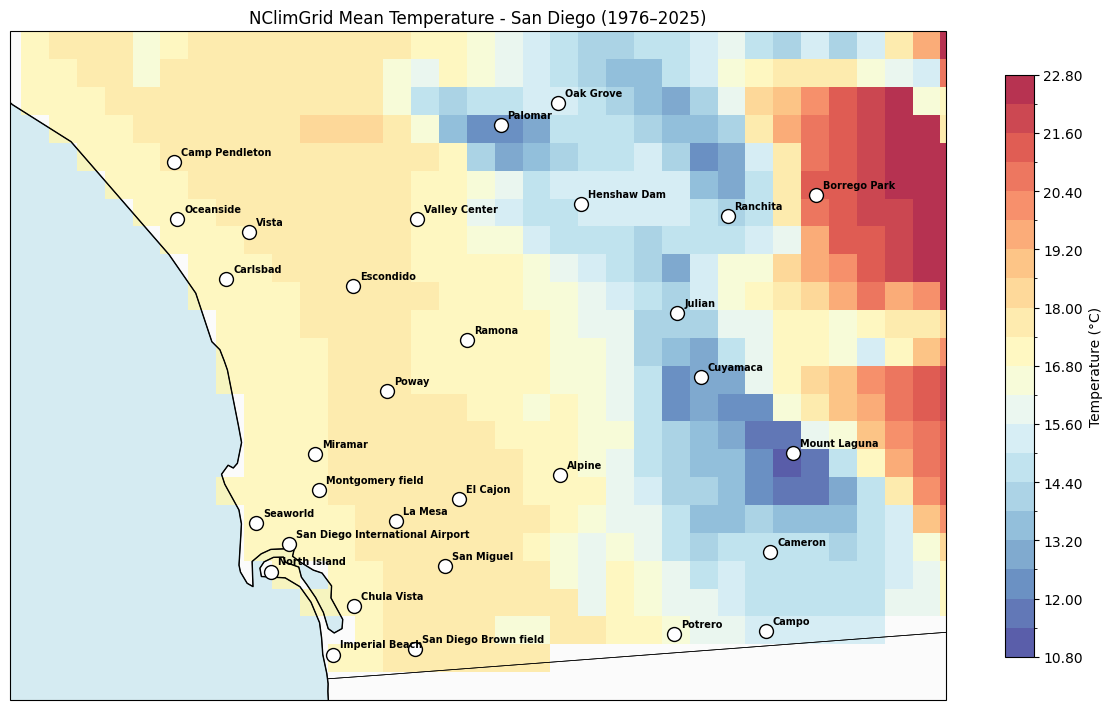

In [208]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# --- subset to San Diego region and time period ---
sd = ds.sel(
    lat=slice(33.5, 32.4),        # reversed because lat is descending
    lon=slice(-117.6, -115.6),
    time=slice('1976-01-01', '2025-01-01')
)

# --- long term mean ---
tavg_mean = sd['tavg'].mean('time')

print(tavg_mean)
print(f"Shape: {tavg_mean.shape}")
print(f"Temp range: {float(tavg_mean.min()):.2f} to {float(tavg_mean.max()):.2f} °C")


# --- discrete colorbar ---
levels = np.arange(10.8, 23.4, 0.6)
cmap   = plt.cm.RdYlBu_r
norm   = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

# --- plot ---
fig, ax = plt.subplots(figsize=(12, 10),
                        subplot_kw={'projection': ccrs.PlateCarree()})

# --- base map ---
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.STATES,    linewidth=0.5)
ax.add_feature(cfeature.OCEAN,     color='lightblue', alpha=0.5)
ax.add_feature(cfeature.LAND,      color='whitesmoke', alpha=0.3)

# --- plot NClimGrid temperature ---
img = ax.pcolormesh(
    sd['lon'], sd['lat'], tavg_mean,
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

# --- station scatter ---
scatter = ax.scatter(lons, lats, color='white',
                     edgecolors='black', s=100, zorder=5,
                     transform=ccrs.PlateCarree())

# --- station labels ---
for name, lat, lon in zip(station_names, lats, lons):
    ax.annotate(name,
                xy=(lon, lat),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=7,
                fontweight='bold',
                zorder=6)

# --- discrete colorbar ---
cbar = plt.colorbar(img, ax=ax, label='Temperature (°C)',
                    shrink=0.6, ticks=levels[::2])
cbar.ax.set_yticklabels([f'{l:.2f}' for l in levels[::2]])

# --- extent ---
ax.set_extent([-117.6, -116.2, 32.5, 33.5], crs=ccrs.PlateCarree())
ax.set_title('NClimGrid Mean Temperature - San Diego (1976–2025)', fontsize=12)
plt.tight_layout()
plt.savefig('NCClimGridTemp.png')
plt.show()

# Linear Regression

In [218]:
#print(new_data.index[:5])
new_data = new_data.T
new_data['elevation(ft)'] = new_data.index.map(lambda name: elev_dict.get(reverse_map.get(name), np.nan))

new_data

Date,1976-01-01 00:00:00,1976-01-02 00:00:00,1976-01-03 00:00:00,1976-01-04 00:00:00,1976-01-05 00:00:00,1976-01-06 00:00:00,1976-01-07 00:00:00,1976-01-08 00:00:00,1976-01-09 00:00:00,1976-01-10 00:00:00,...,2024-12-24 00:00:00,2024-12-25 00:00:00,2024-12-26 00:00:00,2024-12-27 00:00:00,2024-12-28 00:00:00,2024-12-29 00:00:00,2024-12-30 00:00:00,2024-12-31 00:00:00,2025-01-01 00:00:00,elevation(ft)
Brownfield,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,54.0,55.0,54.0,53.0,55.0,53.5,54.0,51.0,52.5,520
ElCajon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,54.0,54.5,55.5,53.0,57.5,54.5,56.0,52.5,53.5,510
ChulaVista,49.5,43.0,43.5,46.5,48.0,50.5,47.5,53.5,52.5,52.0,...,54.5,56.0,55.0,54.0,55.5,54.5,54.5,53.0,51.5,80
Montgomery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,53.0,55.0,54.0,53.0,55.5,53.5,56.0,55.5,54.0,410
ImperialBeach,45.0,46.0,46.5,47.5,51.0,50.5,56.0,53.5,50.0,51.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
SeaWorld,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55.0,56.0,54.5,54.5,54.0,53.5,54.5,55.5,51.5,10
LaMesa,46.0,46.5,48.0,50.5,55.0,52.0,57.0,59.5,54.5,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,520
NorthIsland,49.5,48.5,49.0,50.5,51.0,51.0,55.0,56.0,52.0,54.0,...,55.0,56.0,52.5,53.5,57.0,54.0,55.5,55.0,53.0,10
Alpine,NaN,42.5,48.0,NaN,50.5,50.0,55.0,58.5,56.0,51.0,...,59.0,50.5,50.5,51.5,54.0,57.0,52.0,50.5,56.0,1680
InternationalAirport,50.5,48.0,49.5,51.0,53.5,53.5,56.5,57.5,54.0,57.0,...,57.5,59.0,57.0,55.0,56.5,56.5,57.5,57.0,55.5,10


In [219]:
# --- separate elevation column ---
elevation_col = new_data['elevation(ft)']

# --- drop elevation, convert columns to datetime ---
temp_only = new_data.drop(columns='elevation(ft)')
temp_only.columns = pd.to_datetime(temp_only.columns)

# --- transpose, resample monthly, transpose back ---
new_data_monthly = (temp_only.T
                              .resample('MS')
                              .mean()
                              .T)

# --- add elevation back ---
new_data_monthly['elevation(ft)'] = elevation_col

new_data_monthly.columns = [col.strftime('%Y-%m') if hasattr(col, 'strftime') else col for col in new_data_monthly.columns]
print(new_data_monthly.shape)

(31, 590)


In [220]:
# --- build average dict from your data ---
location_avg = {
    'Brownfield':           17.141344,
    'ElCajon':              18.494571,
    'ChulaVista':           17.451992,
    'Montgomery':           17.827442,
    'ImperialBeach':        16.999353,
    'SeaWorld':             16.904767,
    'LaMesa':               18.301027,
    'NorthIsland':          17.856157,
    'Alpine':               17.720253,
    'InternationalAirport': 18.106014,
    'Miramar':              17.703969,
    'Carlsbad':             16.994026,
    'CampPendleton':        16.923697,
    'Ramona':               16.137777,
    'Oceanside':            16.310620,
    'Cameron':              14.478723,
    'Escondido':            18.614092,
    'MountLaguna':          11.689280,
    'OakGrove':             16.840947,
    'Campo':                15.242345,
    'HenshawDam':           14.113352,
    'Potrero':              16.092398,
    'Julian':               14.808668,
    'Ranchita':             15.978708,
    'SanMiguel':            18.279029,
    'ValleyCenter':         17.866870,
    'Cuyamaca':             12.222831,
    'Vista':                17.637856,
    'BorregoPark':          23.148253,
    'Poway':                18.426425,
    'Palomar':              13.757617
}

location_avg = {k: v * 9/5 + 32 for k, v in location_avg.items()}

# --- fill NaN for each row with its location average ---
date_cols = [col for col in new_data_monthly.columns if col != 'elevation(ft)']

for station, avg in location_avg.items():
    if station in new_data_monthly.index:
        new_data_monthly.loc[station, date_cols] = (
            new_data_monthly.loc[station, date_cols].fillna(avg)
        )

print(new_data_monthly.isnull().sum().sum())  # should be 0

0


In [221]:
new_data_monthly

,1976-01,1976-02,1976-03,1976-04,1976-05,1976-06,1976-07,1976-08,1976-09,1976-10,...,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,elevation(ft)
Brownfield,62.854419,62.854419,62.854419,62.854419,62.854419,62.854419,62.854419,62.854419,62.854419,62.854419,...,62.274194,67.416667,71.983871,72.951613,72.083333,66.693548,59.537037,56.419355,52.500000,520
ElCajon,65.290228,65.290228,65.290228,65.290228,65.290228,65.290228,65.290228,65.290228,65.290228,65.290228,...,63.983871,70.416667,76.467742,76.483871,74.516667,68.935484,58.683333,57.080645,53.500000,510
ChulaVista,54.854839,56.034483,55.758065,56.783333,61.209677,64.900000,67.887097,67.516129,69.883333,65.790323,...,62.548387,66.600000,70.629032,71.290323,71.983333,66.193548,59.216667,55.516129,51.500000,80
Montgomery,64.089396,64.089396,64.089396,64.089396,64.089396,64.089396,64.089396,64.089396,64.089396,64.089396,...,62.403226,67.483333,72.645161,73.935484,72.100000,67.306452,59.700000,57.387097,54.000000,410
ImperialBeach,55.285714,56.103448,56.048387,56.700000,60.887097,64.428571,62.598835,67.178571,69.600000,65.850000,...,62.598835,62.598835,62.598835,62.598835,62.598835,62.598835,62.598835,62.598835,62.598835,10
SeaWorld,62.428581,62.428581,62.428581,62.428581,62.428581,62.428581,62.428581,62.428581,62.428581,62.428581,...,62.290323,66.183333,69.774194,71.048387,69.550000,63.403226,57.200000,54.758065,51.500000,10
LaMesa,59.241935,57.293103,58.306452,58.517241,64.225806,70.483333,71.370968,72.370968,71.625000,69.166667,...,64.941849,64.941849,64.941849,64.941849,64.941849,64.941849,64.941849,64.941849,64.941849,520
NorthIsland,57.354839,57.086207,57.483871,57.683333,63.661290,66.733333,69.370968,71.661290,72.433333,69.000000,...,61.523810,65.833333,70.250000,72.120000,71.282609,64.351852,58.900000,55.935484,53.000000,10
Alpine,58.250000,55.303571,55.150000,57.019231,65.517241,73.925926,74.116667,74.193548,69.689655,67.548387,...,61.483871,70.733333,78.790323,76.516129,74.866667,70.532258,57.166667,56.467742,56.000000,1680
InternationalAirport,58.870968,59.603448,60.306452,60.983333,65.129032,69.683333,71.096774,72.435484,73.766667,71.129032,...,63.241935,67.183333,71.870968,73.612903,72.116667,66.709677,60.566667,57.709677,55.500000,10


In [222]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- separate elevation ---
elevation_col = new_data_monthly['elevation(ft)']
date_cols     = [col for col in new_data_monthly.columns if col != 'elevation(ft)']

# --- melt into long format ---
df_long = new_data_monthly[date_cols].copy()
df_long = df_long.reset_index()
df_long = df_long.melt(id_vars='index', var_name='date', value_name='tavg')
df_long.columns = ['station', 'date', 'tavg']

# --- add features ---
df_long['date']      = pd.to_datetime(df_long['date'])
df_long['month']     = df_long['date'].dt.month
df_long['year']      = df_long['date'].dt.year
df_long['elevation'] = df_long['station'].map(elevation_col)

# --- add lat/lon ---
station_meta = {s[0]: (s[1], s[2]) for s in stations}
df_long['lat'] = df_long['station'].map(
    lambda x: station_meta.get(reverse_map.get(x), (np.nan, np.nan))[0])
df_long['lon'] = df_long['station'].map(
    lambda x: station_meta.get(reverse_map.get(x), (np.nan, np.nan))[1])

df_long = df_long.dropna()
print(df_long.shape)
print(df_long.head())

# --- train/test split by time ---
train = df_long[df_long['year'] <= 2010]
test  = df_long[df_long['year'] >  2010]

features = ['lat', 'lon', 'elevation', 'month', 'year']
X_train, y_train = train[features], train['tavg']
X_test,  y_test  = test[features],  test['tavg']

print(f"Train size: {len(train)} | Test size: {len(test)}")

# --- linear regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"\nLinear Regression")
print(f"R²:   {r2_score(y_test, y_pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f} °F")

# --- random forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"\nRandom Forest")
print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f} °F")


(18259, 8)
         station       date       tavg  month  year  elevation      lat  \
0     Brownfield 1976-01-01  62.854419      1  1976        520  32.5758   
1        ElCajon 1976-01-01  65.290228      1  1976        510  32.8005   
2     ChulaVista 1976-01-01  54.854839      1  1976         80  32.6400   
3     Montgomery 1976-01-01  64.089396      1  1976        410  32.8145   
4  ImperialBeach 1976-01-01  55.285714      1  1976         10  32.5680   

        lon  
0 -116.9939  
1 -116.9280  
2 -117.0858  
3 -117.1375  
4 -117.1172  
Train size: 13020 | Test size: 5239

Linear Regression
R²:   0.2001
RMSE: 8.2037 °F

Random Forest
R²:   0.8266
RMSE: 3.8196 °F


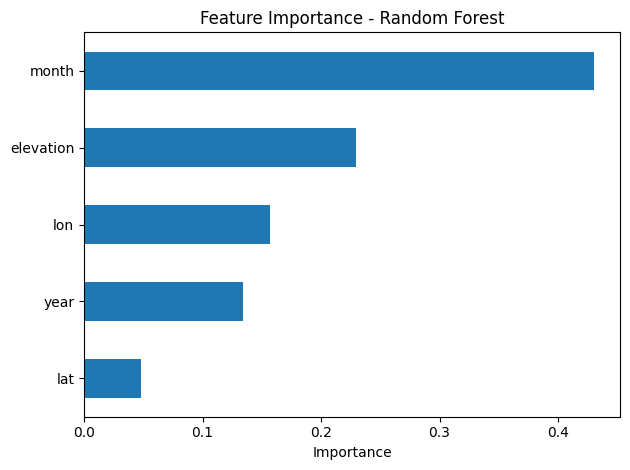

In [223]:
# --- feature importance ---

importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('randomforest_features.png')
plt.show()

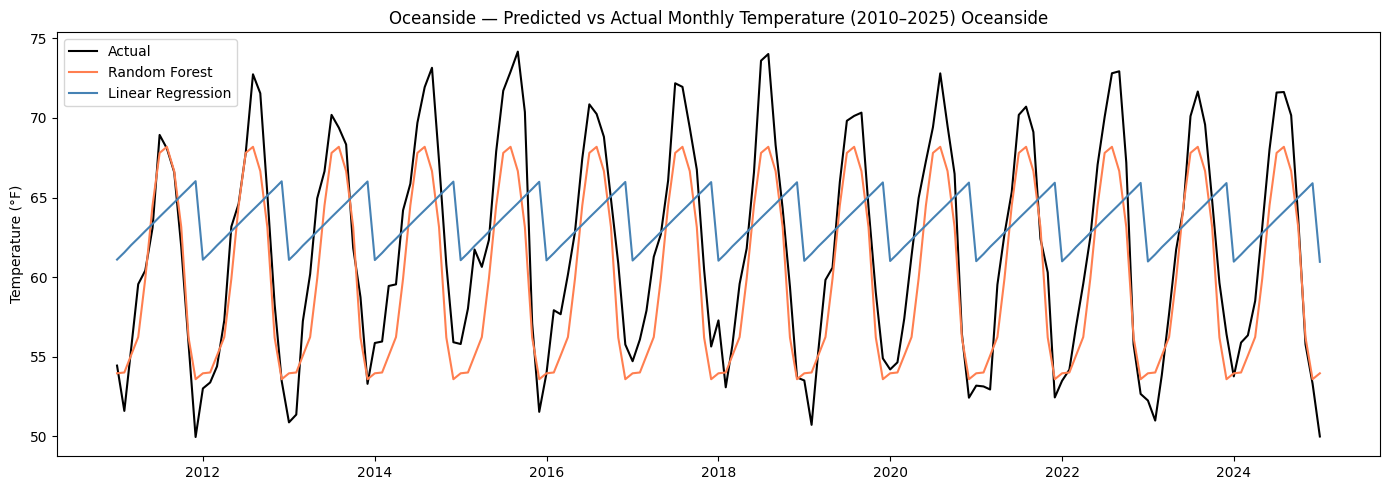

In [224]:
# --- add predictions to test set ---
test = test.copy()
test['pred_lr'] = y_pred_lr
test['pred_rf'] = y_pred_rf

# --- plot one station ---
station = 'Oceanside'
subset  = test[test['station'] == station].sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(subset['date'], subset['tavg'],    label='Actual',           color='black')
plt.plot(subset['date'], subset['pred_rf'], label='Random Forest',    color='coral')
plt.plot(subset['date'], subset['pred_lr'], label='Linear Regression',color='steelblue')
plt.title(f'{station} — Predicted vs Actual Monthly Temperature (2010–2025) Oceanside')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.tight_layout()
plt.savefig('oceanside_predic.png')
plt.show()

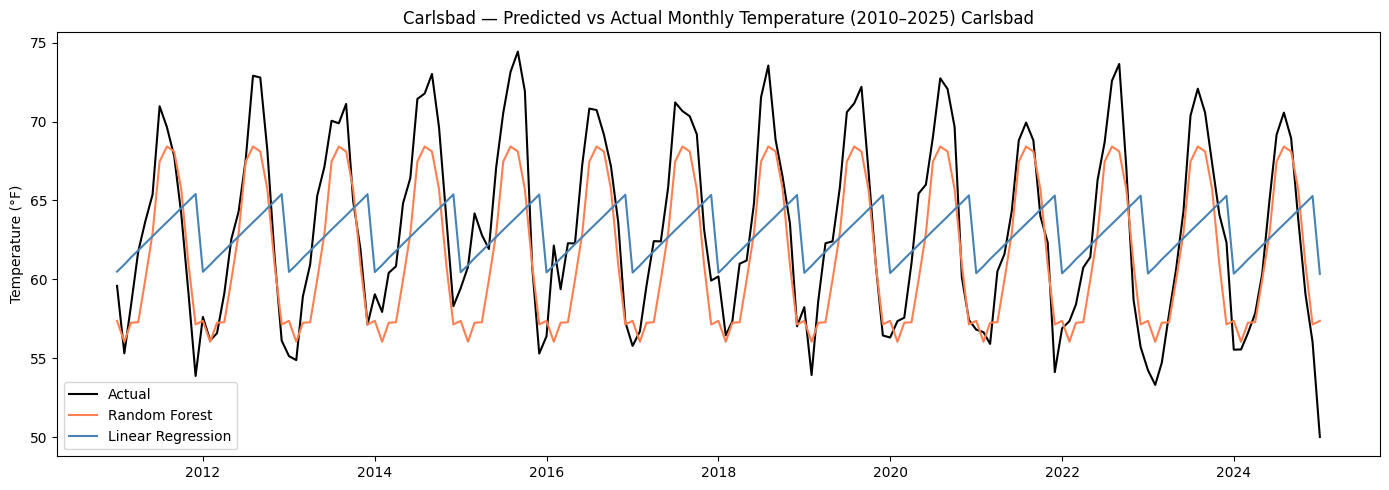

In [226]:
test = test.copy()
test['pred_lr'] = y_pred_lr
test['pred_rf'] = y_pred_rf

# --- plot one station ---
station = 'Carlsbad'
subset  = test[test['station'] == station].sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(subset['date'], subset['tavg'],    label='Actual',           color='black')
plt.plot(subset['date'], subset['pred_rf'], label='Random Forest',    color='coral')
plt.plot(subset['date'], subset['pred_lr'], label='Linear Regression',color='steelblue')
plt.title(f'{station} — Predicted vs Actual Monthly Temperature (2010–2025) Carlsbad')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.tight_layout()
plt.savefig('carlsbad_predic.png')
plt.show()

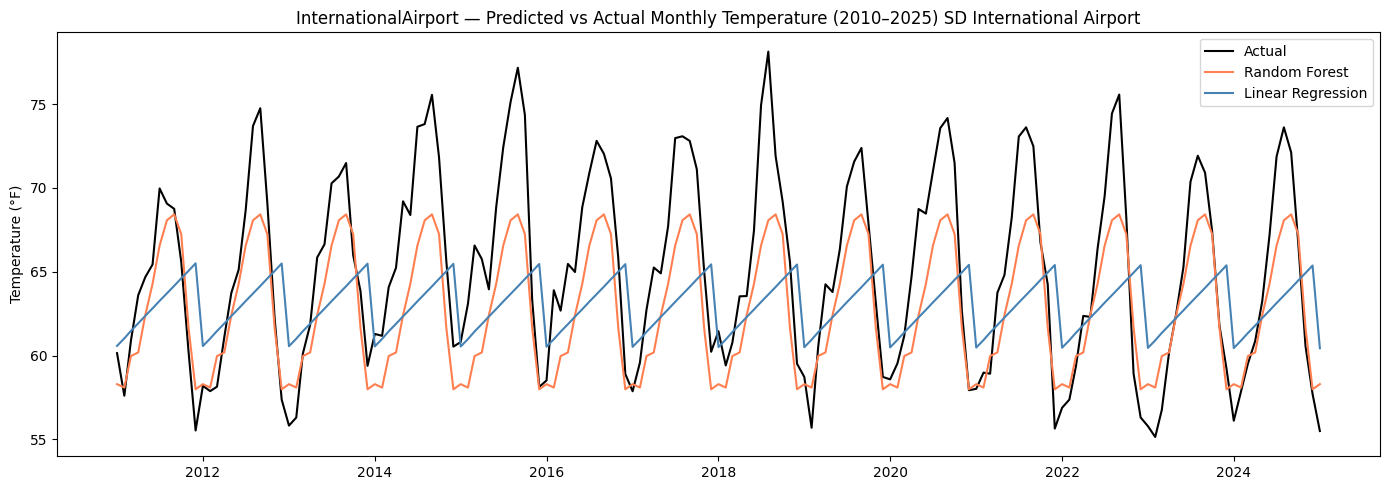

In [140]:
# --- add predictions to test set ---
test = test.copy()
test['pred_lr'] = y_pred_lr
test['pred_rf'] = y_pred_rf

# --- plot one station ---
station = 'InternationalAirport'
subset  = test[test['station'] == station].sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(subset['date'], subset['tavg'],    label='Actual',           color='black')
plt.plot(subset['date'], subset['pred_rf'], label='Random Forest',    color='coral')
plt.plot(subset['date'], subset['pred_lr'], label='Linear Regression',color='steelblue')
plt.title(f'{station} — Predicted vs Actual Monthly Temperature (2010–2025) SD International Airport')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.tight_layout()
plt.savefig('SDX_predic.png')
plt.show()

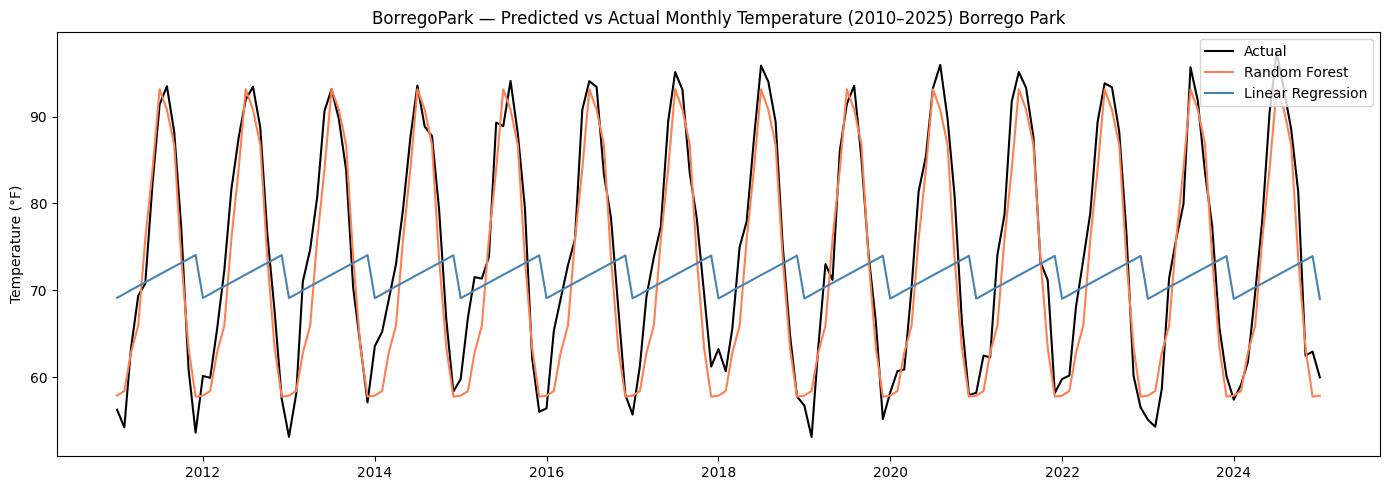

In [227]:
# --- add predictions to test set ---
test = test.copy()
test['pred_lr'] = y_pred_lr
test['pred_rf'] = y_pred_rf

# --- plot one station ---
station = 'BorregoPark'
subset  = test[test['station'] == station].sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(subset['date'], subset['tavg'],    label='Actual',           color='black')
plt.plot(subset['date'], subset['pred_rf'], label='Random Forest',    color='coral')
plt.plot(subset['date'], subset['pred_lr'], label='Linear Regression',color='steelblue')
plt.title(f'{station} — Predicted vs Actual Monthly Temperature (2010–2025) Borrego Park')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.tight_layout()
plt.savefig('Borregopark_predic.png')
plt.show()

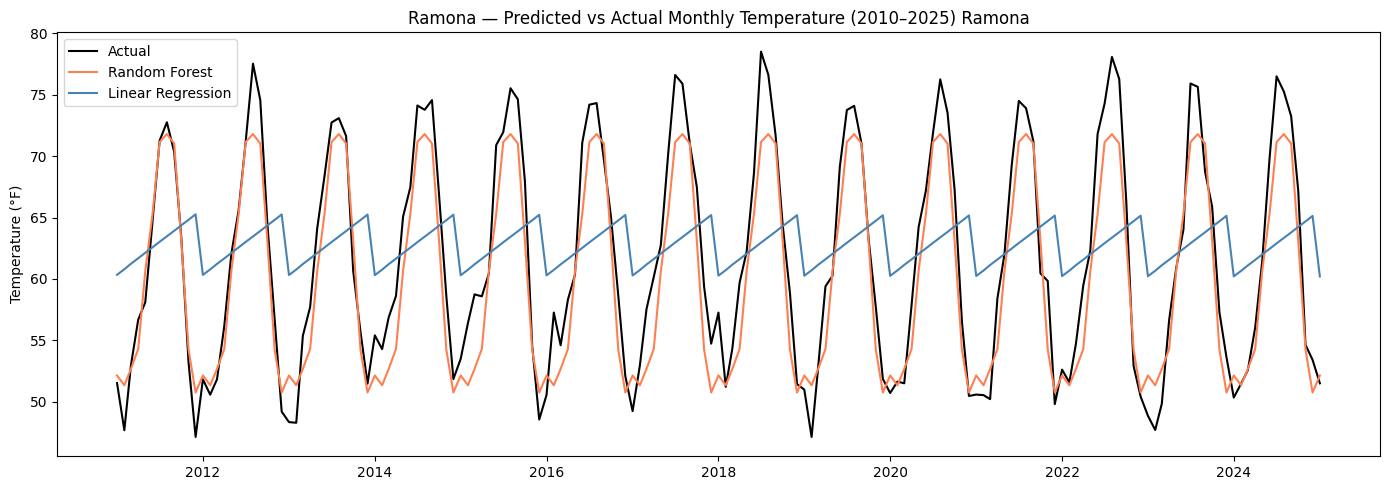

In [141]:
# --- add predictions to test set ---
test = test.copy()
test['pred_lr'] = y_pred_lr
test['pred_rf'] = y_pred_rf

# --- plot one station ---
station = 'Ramona'
subset  = test[test['station'] == station].sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(subset['date'], subset['tavg'],    label='Actual',           color='black')
plt.plot(subset['date'], subset['pred_rf'], label='Random Forest',    color='coral')
plt.plot(subset['date'], subset['pred_lr'], label='Linear Regression',color='steelblue')
plt.title(f'{station} — Predicted vs Actual Monthly Temperature (2010–2025) Ramona')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.tight_layout()
plt.savefig('Ramona_predic.png')
plt.show()

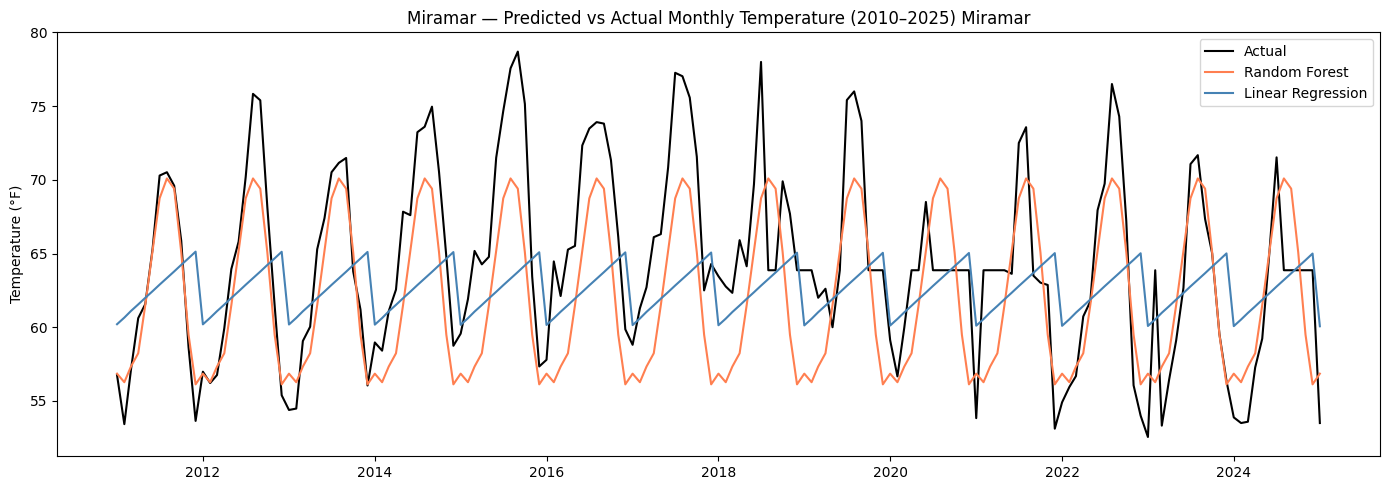

In [142]:
# --- add predictions to test set ---
test = test.copy()
test['pred_lr'] = y_pred_lr
test['pred_rf'] = y_pred_rf

# --- plot one station ---
station = 'Miramar'
subset  = test[test['station'] == station].sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(subset['date'], subset['tavg'],    label='Actual',           color='black')
plt.plot(subset['date'], subset['pred_rf'], label='Random Forest',    color='coral')
plt.plot(subset['date'], subset['pred_lr'], label='Linear Regression',color='steelblue')
plt.title(f'{station} — Predicted vs Actual Monthly Temperature (2010–2025) Miramar')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.tight_layout()
plt.savefig('Miramar_predic.png')
plt.show()

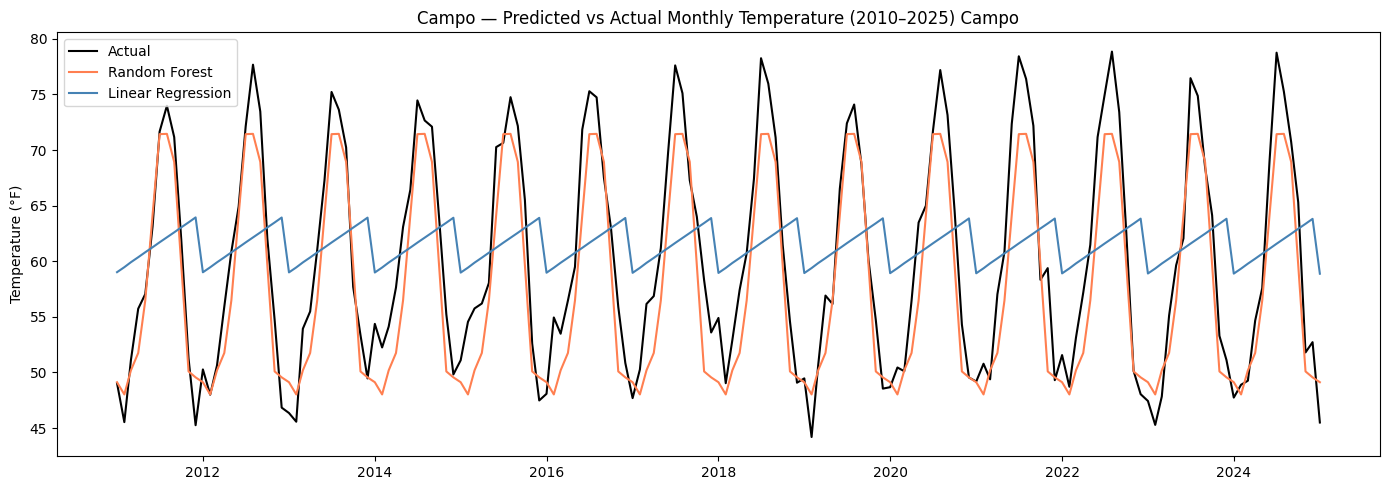

In [228]:
# --- add predictions to test set ---
test = test.copy()
test['pred_lr'] = y_pred_lr
test['pred_rf'] = y_pred_rf

# --- plot one station ---
station = 'Campo'
subset  = test[test['station'] == station].sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(subset['date'], subset['tavg'],    label='Actual',           color='black')
plt.plot(subset['date'], subset['pred_rf'], label='Random Forest',    color='coral')
plt.plot(subset['date'], subset['pred_lr'], label='Linear Regression',color='steelblue')
plt.title(f'{station} — Predicted vs Actual Monthly Temperature (2010–2025) Campo')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.tight_layout()
plt.savefig('Campo_predic.png')
plt.show()

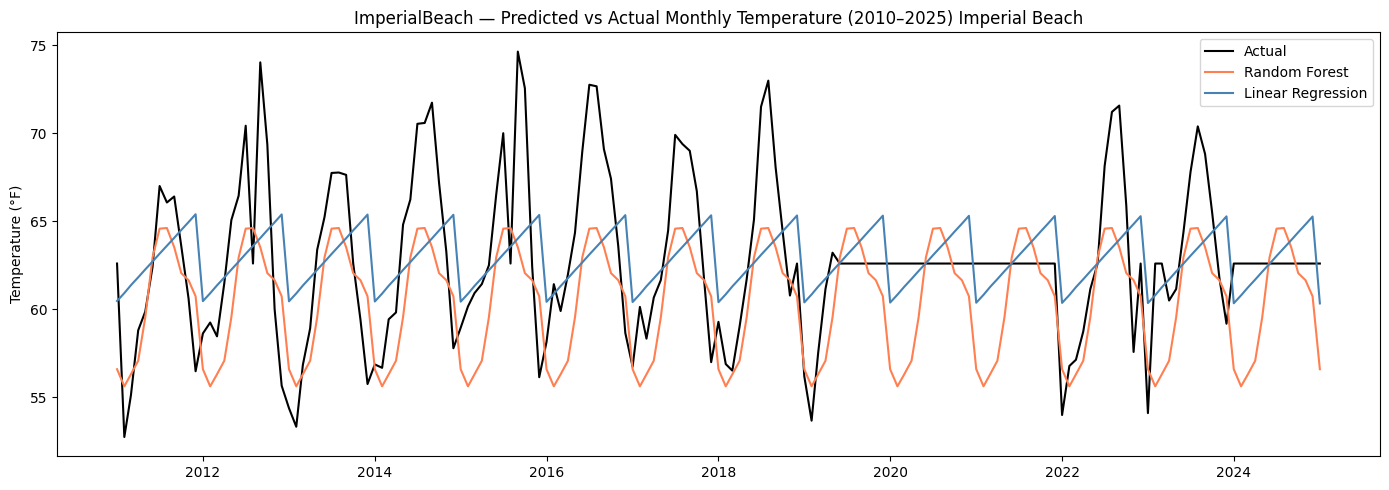

In [229]:
# --- add predictions to test set ---
test = test.copy()
test['pred_lr'] = y_pred_lr
test['pred_rf'] = y_pred_rf

# --- plot one station ---
station = 'ImperialBeach'
subset  = test[test['station'] == station].sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(subset['date'], subset['tavg'],    label='Actual',           color='black')
plt.plot(subset['date'], subset['pred_rf'], label='Random Forest',    color='coral')
plt.plot(subset['date'], subset['pred_lr'], label='Linear Regression',color='steelblue')
plt.title(f'{station} — Predicted vs Actual Monthly Temperature (2010–2025) Imperial Beach')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.tight_layout()
plt.savefig('ImperialBeach_predic.png')
plt.show()

             Station   RMSE_LR  RMSE_RF
              LaMesa  2.362956 0.449924
               Vista  6.148961 2.749076
            Carlsbad  5.331495 2.871738
         NorthIsland  5.766205 2.878938
           Oceanside  6.596190 2.916617
             ElCajon  7.620244 3.058811
              Ramona  8.750723 3.115237
            SeaWorld  5.040465 3.210911
            OakGrove  9.886950 3.232266
          ChulaVista  5.529699 3.292935
           SanMiguel  5.835369 3.301854
         MountLaguna 10.581641 3.501436
InternationalAirport  5.763646 3.535862
          Brownfield  6.230621 3.562182
             Potrero  9.068627 3.629184
        ValleyCenter  7.822016 3.698950
          Montgomery  6.722462 3.728109
             Cameron  9.835523 3.741356
               Campo  9.558585 3.812598
            Cuyamaca 10.657726 3.818823
              Alpine  8.546144 3.841715
         BorregoPark 13.172707 3.970509
       ImperialBeach  4.194100 4.038980
              Julian 10.808922 4.062074


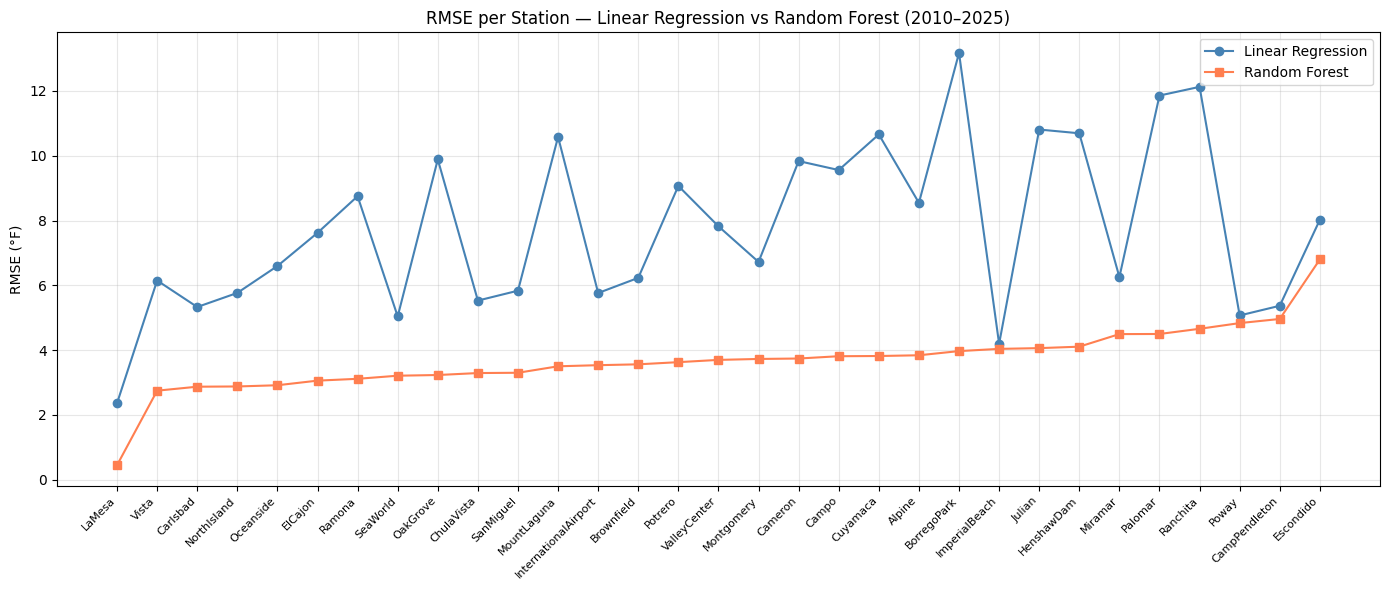

In [197]:
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

test = test.copy()
test['pred_lr'] = y_pred_lr
test['pred_rf'] = y_pred_rf

# --- RMSE per station ---
results = []
for station in test['station'].unique():
    subset   = test[test['station'] == station]
    rmse_lr  = np.sqrt(mean_squared_error(subset['tavg'], subset['pred_lr']))
    rmse_rf  = np.sqrt(mean_squared_error(subset['tavg'], subset['pred_rf']))
    results.append((station, rmse_lr, rmse_rf))

rmse_df = pd.DataFrame(results, columns=['Station', 'RMSE_LR', 'RMSE_RF'])
rmse_df = rmse_df.sort_values('RMSE_RF')
print(rmse_df.to_string(index=False))

# --- plot ---
x     = np.arange(len(rmse_df))
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x, rmse_df['RMSE_LR'], marker='o', linestyle='-', color='steelblue', label='Linear Regression')
ax.plot(x, rmse_df['RMSE_RF'], marker='s', linestyle='-', color='coral',     label='Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(rmse_df['Station'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('RMSE (°F)')
ax.set_title('RMSE per Station — Linear Regression vs Random Forest (2010–2025)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('RMSE_both.png')
plt.show()